In [ ]:
# Import libraries
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from google.cloud import bigquery
import pickle
from datetime import datetime, timezone
import warnings
warnings.filterwarnings('ignore')

PROJECT_ID = 'musa5090s26-team5'
client = bigquery.Client(project=PROJECT_ID)

# Load pre-joined training data (assessments, PWD parcels, SEPTA proximity, geographic_ward)
query = """
SELECT *
FROM `musa5090s26-team5.derived.current_assessments_model_training_data`
WHERE total_livable_area IS NOT NULL
    AND total_livable_area > 0
"""

df = client.query(query).to_dataframe(create_bqstorage_client=False)
print(f"Training data rows: {len(df):,}")
print(df.dtypes)
df.head()

Training data rows: 129,521
parcel_number                  str
sale_price                 float64
sale_date                   dbdate
sale_year                    Int64
total_livable_area         float64
total_area                 float64
year_built                 float64
property_age                 Int64
exterior_condition         float64
interior_condition         float64
condition_score            float64
number_of_bedrooms         float64
number_of_bathrooms        float64
zoning                         str
assessed_value_2023        float64
assessed_value_2024        float64
assessed_value_2025        float64
pct_change_2023_to_2025    float64
lot_area_sqft              float64
lot_perimeter              float64
lot_shape_ratio            float64
dist_to_septa_miles        float64
neighborhood                   str
dtype: object


,parcel_number,sale_price,sale_date,sale_year,total_livable_area,total_area,year_built,property_age,exterior_condition,interior_condition,...,zoning,assessed_value_2023,assessed_value_2024,assessed_value_2025,pct_change_2023_to_2025,lot_area_sqft,lot_perimeter,lot_shape_ratio,dist_to_septa_miles,neighborhood
0,124051100,9500.0,2019-11-18,2019,1815.0,878.0,2026.0,0,1.0,1.0,...,RSA5,18700.0,18700.0,19100.0,2.14,153.167969,59.900510,0.042688,0.106919,GERMANTOWN_WESTSIDE
1,362158405,265000.0,2026-02-06,2026,1036.0,700.0,2026.0,0,1.0,1.0,...,RSA6,81600.0,81600.0,81600.0,0.00,NaN,NaN,NaN,0.054753,GRAYS_FERRY
2,888001862,319000.0,2025-02-24,2025,1076.0,0.0,2025.0,1,1.0,1.0,...,RSD3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.050211,WYNNEFIELD_HEIGHTS
3,011403000,492000.0,2025-04-07,2025,1470.0,676.0,2025.0,1,1.0,1.0,...,RSA5,NaN,NaN,NaN,NaN,109.097656,49.706025,0.044157,0.130732,DICKINSON_NARROWS
4,252000019,265000.0,2025-07-30,2025,1132.0,1296.0,2025.0,1,1.0,1.0,...,RSA6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.144369,RICHMOND


Training rows after filtering: 128,251
Training model...
MAE: $43,635
R²: 0.8821
Best n_estimators (min test MAE): 200
Train MAE at best: $41,288
Test MAE at best: $43,635
Train/test gap: $2,347 (larger = more overfit)


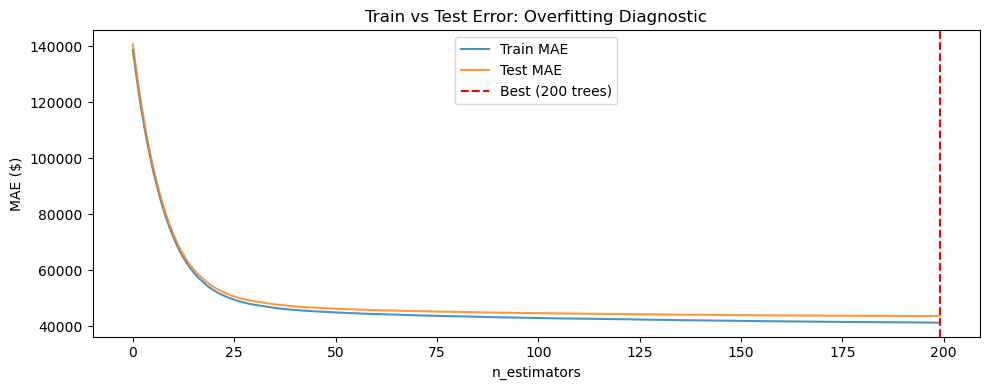


Feature importances (high to low):
FEATURE                        IMPORTANCE CUMULATIVE
neighborhood_median_price          0.4721     47.2%
assessed_value_2025                0.2203     69.2%
total_livable_area                 0.1391     83.1%
sale_year                          0.0489     88.0%
number_of_bathrooms                0.0379     91.8%
assessed_value_2024                0.0317     95.0%
interior_condition                 0.0166     96.7%
assessed_value_2023                0.0132     98.0%
property_age                       0.0121     99.2%
neighborhood                       0.0081    100.0%


<Figure size 800x600 with 0 Axes>

Text(0.5, 1.0, 'Feature Importance (GBR)')

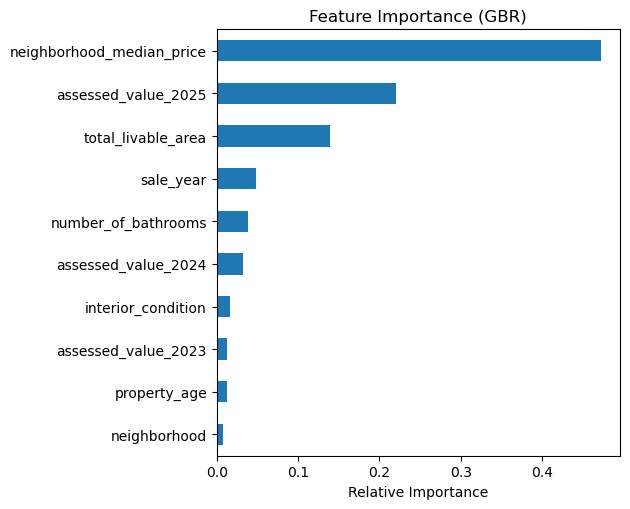

In [20]:
# Features sourced directly from the training table
source_features = [
    # OPA Properties
    'total_livable_area',
    'number_of_bathrooms', 'property_age',
    'interior_condition',
    # OPA Assessments
    'assessed_value_2023', 'assessed_value_2024', 'assessed_value_2025',
    # Location (neighborhoods from spatial join)
    'neighborhood',
    # Sale context
    'sale_year',
]

categorical_features = ['neighborhood']

df_model = df[source_features + ['sale_price']].copy()

# Spatial lag: median sale price per neighborhood (computed before encoding)
neighborhood_price_map = (
    df_model.groupby('neighborhood')['sale_price']
    .median()
    .to_dict()
)
global_price_fallback = df_model['sale_price'].median()
df_model['neighborhood_median_price'] = (
    df_model['neighborhood']
    .map(neighborhood_price_map)
    .fillna(global_price_fallback)
)

# Full feature list includes the derived spatial lag
features = source_features + ['neighborhood_median_price']

# Fill nulls and encode categoricals — persist encoders for reuse at prediction time
label_encoders = {}
medians = {}
for col in features:
    if col in categorical_features or df_model[col].dtype == 'object':
        df_model[col] = df_model[col].fillna('Unknown').astype(str)
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col])
        label_encoders[col] = le
    else:
        med = df_model[col].median()
        df_model[col] = df_model[col].fillna(med)
        medians[col] = med

# Remove extreme outliers in sale_price
q99 = df_model['sale_price'].quantile(0.99)
df_model = df_model[df_model['sale_price'] <= q99]

print(f"Training rows after filtering: {len(df_model):,}")

# Train/test split
X = df_model[features]
y = df_model['sale_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
print("Training model...")
model = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: ${mae:,.0f}")
print(f"R²: {r2:.4f}")

# Overfitting check
train_maes = [mean_absolute_error(y_train, yp) for yp in model.staged_predict(X_train)]
test_maes  = [mean_absolute_error(y_test,  yp) for yp in model.staged_predict(X_test)]
best_n = int(np.argmin(test_maes)) + 1
print(f"Best n_estimators (min test MAE): {best_n}")
print(f"Train MAE at best: ${train_maes[best_n - 1]:,.0f}")
print(f"Test MAE at best: ${test_maes[best_n - 1]:,.0f}")
print(f"Train/test gap: ${test_maes[best_n - 1] - train_maes[best_n - 1]:,.0f} (larger = more overfit)")

plt.figure(figsize=(10, 4))
plt.plot(train_maes, label='Train MAE', alpha=0.8)
plt.plot(test_maes,  label='Test MAE',  alpha=0.8)
plt.axvline(best_n - 1, color='red', linestyle='--', label=f'Best ({best_n} trees)')
plt.xlabel('n_estimators')
plt.ylabel('MAE ($)')
plt.title('Train vs Test Error: Overfitting Diagnostic')
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance with all features ranked, so low-value ones can be identified and dropped
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature importances (high to low):")
print(f"{'FEATURE':<30} {'IMPORTANCE':>10} {'CUMULATIVE':>10}")
cumulative = 0.0
for feat, imp in importances.items():
    cumulative += imp
    marker = ' (consider dropping)' if imp < 0.005 else ''
    print(f"{feat:<30} {imp:>10.4f} {cumulative:>9.1%}{marker}")

plt.figure(figsize=(8, 6))
plt.show()

importances.sort_values(ascending=True).plot.barh()
plt.tight_layout()

plt.xlabel('Relative Importance')
plt.title('Feature Importance (GBR)')

In [17]:
# Save model + encoders + medians for reproducibility
with open('model.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'label_encoders': label_encoders,
        'medians': medians,
        'neighborhood_price_map': neighborhood_price_map,
        'global_price_fallback': global_price_fallback,
    }, f)
print("Model and encoders saved.")

# Load ALL residential properties with same feature joins as training data
query_all = """
WITH medians AS (
    SELECT
        PERCENTILE_CONT(SAFE_CAST(total_livable_area AS FLOAT64), 0.5) OVER () AS median_total_livable_area,
        PERCENTILE_CONT(SAFE_CAST(year_built AS FLOAT64), 0.5) OVER () AS median_year_built,
        PERCENTILE_CONT(SAFE_CAST(number_of_bedrooms AS FLOAT64), 0.5) OVER () AS median_bedrooms,
        PERCENTILE_CONT(SAFE_CAST(number_of_bathrooms AS FLOAT64), 0.5) OVER () AS median_bathrooms
    FROM `musa5090s26-team5.core.opa_properties`
    WHERE category_code = '1'
    LIMIT 1
),

mode_conditions AS (
    SELECT
        APPROX_TOP_COUNT(SAFE_CAST(exterior_condition AS FLOAT64), 1)[OFFSET(0)].value AS mode_exterior,
        APPROX_TOP_COUNT(SAFE_CAST(interior_condition AS FLOAT64), 1)[OFFSET(0)].value AS mode_interior
    FROM `musa5090s26-team5.core.opa_properties`
    WHERE
        category_code = '1'
        AND exterior_condition IS NOT NULL
        AND interior_condition IS NOT NULL
),

assessments_pivot AS (
    SELECT
        parcel_number,
        MAX(CASE WHEN year = 2023.0 THEN market_value END) AS assessed_value_2023,
        MAX(CASE WHEN year = 2024.0 THEN market_value END) AS assessed_value_2024,
        MAX(CASE WHEN year = 2025.0 THEN market_value END) AS assessed_value_2025
    FROM `musa5090s26-team5.core.opa_assessments`
    WHERE market_value IS NOT NULL AND market_value > 0
    GROUP BY parcel_number
),

pwd AS (
    SELECT
        brt_id,
        shape__area AS lot_area_sqft,
        SAFE_DIVIDE(shape__area, shape__length * shape__length) AS lot_shape_ratio
    FROM `musa5090s26-team5.core.pwd_parcels`
    WHERE brt_id IS NOT NULL AND shape__area > 0
),

septa_dist AS (
    SELECT
        p.parcel_number,
        MIN(ST_DISTANCE(
            p.geometry,
            ST_GEOGPOINT(SAFE_CAST(s.longitude AS FLOAT64), SAFE_CAST(s.latitude AS FLOAT64))
        )) / 1609.34 AS dist_to_septa_miles
    FROM `musa5090s26-team5.core.opa_properties` AS p
    CROSS JOIN `musa5090s26-team5.core.septa` AS s
    WHERE
        p.category_code = '1'
        AND s.longitude IS NOT NULL AND s.latitude IS NOT NULL
        AND p.geometry IS NOT NULL
    GROUP BY p.parcel_number
),

prop_neighborhood AS (
    SELECT
        p.parcel_number,
        n.name AS neighborhood
    FROM `musa5090s26-team5.core.opa_properties` AS p
    INNER JOIN `musa5090s26-team5.core.neighborhoods` AS n
        ON ST_CONTAINS(ST_GEOGFROMWKB(n.geometry), p.geometry)
    WHERE
        p.category_code = '1'
        AND p.geometry IS NOT NULL
)

SELECT
    p.parcel_number,
    COALESCE(SAFE_CAST(p.total_livable_area AS FLOAT64), m.median_total_livable_area) AS total_livable_area,
    COALESCE(SAFE_CAST(p.number_of_bathrooms AS FLOAT64), m.median_bathrooms) AS number_of_bathrooms,
    EXTRACT(YEAR FROM CURRENT_DATE()) - CAST(COALESCE(SAFE_CAST(p.year_built AS FLOAT64), m.median_year_built) AS INT64) AS property_age,
    COALESCE(SAFE_CAST(p.interior_condition AS FLOAT64), mc.mode_interior) AS interior_condition,
    a.assessed_value_2023,
    a.assessed_value_2024,
    a.assessed_value_2025,
    pn.neighborhood,
    EXTRACT(YEAR FROM CURRENT_DATE()) AS sale_year
FROM `musa5090s26-team5.core.opa_properties` AS p
CROSS JOIN medians AS m
CROSS JOIN mode_conditions AS mc
LEFT JOIN assessments_pivot AS a
    ON CAST(a.parcel_number AS STRING) = p.parcel_number
LEFT JOIN pwd
    ON CAST(pwd.brt_id AS STRING) = p.parcel_number
LEFT JOIN septa_dist AS sd
    ON sd.parcel_number = p.parcel_number
LEFT JOIN prop_neighborhood AS pn
    ON pn.parcel_number = p.parcel_number
WHERE
    p.category_code = '1'
    AND SAFE_CAST(p.total_livable_area AS FLOAT64) IS NOT NULL
    AND SAFE_CAST(p.total_livable_area AS FLOAT64) > 0
"""

df_all = client.query(query_all).to_dataframe(create_bqstorage_client=False)
print(f"Properties to predict: {len(df_all):,}")

# Add spatial lag using neighborhood medians learned from training data
df_all['neighborhood_median_price'] = (
    df_all['neighborhood']
    .fillna('Unknown')
    .map(neighborhood_price_map)
    .fillna(global_price_fallback)
)

# Apply same encoding using stored encoders from training
df_pred = df_all[features].copy()
for col in features:
    if col in label_encoders:
        le = label_encoders[col]
        known_classes = set(le.classes_)
        fallback = 'Unknown' if 'Unknown' in known_classes else le.classes_[0]
        df_pred[col] = df_pred[col].fillna('Unknown').astype(str)
        df_pred[col] = df_pred[col].apply(lambda x: x if x in known_classes else fallback)
        df_pred[col] = le.transform(df_pred[col])
    else:
        med = medians.get(col, df_pred[col].median())
        df_pred[col] = df_pred[col].fillna(med)

# Predict
predicted_values = model.predict(df_pred)
predicted_at = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')

df_results = pd.DataFrame({
    'property_id': df_all['parcel_number'],
    'predicted_value': predicted_values.round(2),
    'predicted_at': predicted_at
})

print(df_results.head())
print(f"Total predictions: {len(df_results):,}")

Model and encoders saved.
Properties to predict: 462,669
  property_id  predicted_value         predicted_at
0   395000007        613281.23  2026-04-16 18:56:14
1   212514432        664029.21  2026-04-16 18:56:14
2   212514412        520139.13  2026-04-16 18:56:14
3   521000012        436734.92  2026-04-16 18:56:14
4   888001871        315781.88  2026-04-16 18:56:14
Total predictions: 462,669


In [18]:
# Write predictions to BigQuery
table_id = 'musa5090s26-team5.derived.current_assessments'

job_config = bigquery.LoadJobConfig(
    write_disposition='WRITE_TRUNCATE',
    schema=[
        bigquery.SchemaField('property_id', 'STRING'),
        bigquery.SchemaField('predicted_value', 'FLOAT64'),
        bigquery.SchemaField('predicted_at', 'STRING'),
    ]
)

job = client.load_table_from_dataframe(df_results, table_id, job_config=job_config)
job.result()

print(f"Loaded {len(df_results):,} rows to {table_id}")

Loaded 462,669 rows to musa5090s26-team5.derived.current_assessments


Removed below features due to low importance for a parsimonious model.

Feature | Importance | Cumulative
|-|-|-|
total_area | 0.0048 | 98.8%
pct_change_2023_to_2025 | 0.0023 | 99.1%
lot_area_sqft | 0.0020 | 99.3%
lot_shape_ratio | 0.0017 | 99.4%
dist_to_septa_miles | 0.0015 | 99.6%
condition_score | 0.0013 | 99.7%
zoning | 0.0012 | 99.8%
number_of_bedrooms | 0.0011 | 99.9%
exterior_condition | 0.0007 | 100.0%